In [ ]:
import pandas as pd

df = pd.read_csv("../dataset/customer_churn.csv")

df.head()

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df['TotalCharges'].str.strip().eq('').sum()

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df['TotalCharges'].isnull().sum()

In [ ]:
df = df.dropna(subset=['TotalCharges'])


In [ ]:
df.shape

In [ ]:
df.duplicated().sum()

In [ ]:
df['Churn'].value_counts()


In [ ]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
churn_percentage = df['Churn'].value_counts(normalize=True) * 100
churn_percentage

In [ ]:
df['tenure'].describe()

In [ ]:
plt.hist(df['tenure'], bins=20)

plt.title('Customer Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
df['MonthlyCharges'].describe()

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
import pandas as pd

df = pd.read_csv("../dataset/customer_churn.csv")

df.head()

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['MonthlyCharges'], bins=20)

plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
df.groupby('Contract')['Churn'].value_counts()

In [ ]:
df.groupby('Contract')['Churn'].value_counts()

In [ ]:
df.groupby('InternetService')['Churn'].value_counts()

In [ ]:
df.groupby('InternetService')['Churn'].value_counts().unstack().plot(kind='bar')

plt.title('Churn vs Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [ ]:
df = df.drop('customerID', axis=1)

df.head()

In [ ]:
df = pd.get_dummies(df, drop_first=True)

df.head()

In [ ]:
import pandas as pd

df = pd.read_csv("../dataset/customer_churn.csv")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna(subset=['TotalCharges'])

df = df.drop('customerID', axis=1)

df = pd.get_dummies(df, drop_first=True)

df.shape

In [ ]:
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

print("X shape:", X.shape)
print("y shape:", y.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)

print("Model training completed successfully!")

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Make predictions
y_pred = model.predict(X_test)

# Get probability of Churn = Yes
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve - Customer Churn Prediction')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
import joblib

joblib.dump(model, "../models/customer_churn_model.pkl")

print("Model saved successfully!")

In [ ]:
import os

print(os.getcwd())

In [ ]:
import os

print("Models folder exists:", os.path.exists("../models"))

In [ ]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder created successfully!")

In [ ]:
import joblib

joblib.dump(model, "../models/customer_churn_model.pkl")

print("Model saved successfully!")

In [ ]:
import joblib

loaded_model = joblib.load("../models/customer_churn_model.pkl")

print("Saved model loaded successfully!")

# Customer Churn Prediction

## Data Science Internship Project

This project aims to predict which customers are likely to stop using a service based on their historical behavior and customer information.

### Objectives
- Perform data preprocessing and cleaning
- Explore customer churn patterns through EDA
- Select important features
- Build a Logistic Regression classification model
- Evaluate the model using Accuracy and ROC-AUC

In [ ]:
## 1. Dataset

The dataset contains customer information and their service usage details. 
The target variable is `Churn`, which indicates whether a customer has stopped using the service.

### Dataset Size

- Original records: 7,043
- Original features: 21
- Records after cleaning: 7,032
- Features used for modeling: 30 after encoding categorical variables

## 1. Dataset

The dataset contains customer information and their service usage details. 
The target variable is `Churn`, which indicates whether a customer has stopped using the service.

### Dataset Size

- Original records: 7,043
- Original features: 21
- Records after cleaning: 7,032
- Features used for modeling: 30 after encoding categorical variables

## 2. Data Preprocessing and Cleaning

The dataset was inspected and cleaned before building the machine learning model.

### Steps performed

1. Checked the dataset shape and column names.
2. Checked for missing values.
3. Converted `TotalCharges` from text to numeric format.
4. Found 11 missing values in `TotalCharges` after conversion.
5. Removed the 11 records with missing `TotalCharges`.
6. Checked for duplicate records.
7. Removed `customerID` because it is an identifier and does not provide useful information for prediction.
8. Converted categorical variables into numerical form using one-hot encoding.
9. Separated the dataset into input features (`X`) and target variable (`y`).

## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand customer behavior and identify patterns related to churn.

The following aspects were analyzed:

- Overall customer churn distribution
- Tenure distribution
- Monthly charges distribution
- Churn based on contract type
- Churn based on internet service type

These visualizations help identify customer groups that may have a higher tendency to churn.

### 3.1 Churn Distribution

The distribution of customers who stayed with the service and those who churned was analyzed.

### 3.2 Tenure Distribution

Customer tenure was analyzed to understand how long customers had been using the service.

In [ ]:
### 3.3 Monthly Charges Distribution

The distribution of monthly charges was analyzed to understand the range of charges paid by customers.

### 3.3 Monthly Charges Distribution

The distribution of monthly charges was analyzed to understand the range of charges paid by customers.

### 3.4 Churn vs Contract Type

Customer churn was compared across different contract types to identify whether contract duration is associated with customer churn.

### 3.5 Churn vs Internet Service

Customer churn was compared across different internet service types to identify differences in churn behavior.

## 4. Feature Selection

Feature selection was performed to identify the most relevant features for predicting customer churn.

The `customerID` column was removed because it is only a customer identifier. Categorical variables were converted into numerical variables using one-hot encoding.

The `SelectKBest` method with the ANOVA F-test (`f_classif`) was then used to select the **10 most relevant features** for the Logistic Regression model.

## 5. Train-Test Split

The dataset was divided into training and testing sets.

- **80%** of the data was used for training the model.
- **20%** of the data was used for testing the model.
- `stratify=y` was used to maintain the same churn class proportion in both sets.

### Dataset Split

- Training data: **5,625 records**
- Testing data: **1,407 records**

In [ ]:
## 6. Model Building

Logistic Regression was selected as the classification algorithm to predict customer churn.

A machine learning pipeline was created with the following steps:

1. Select the 10 most relevant features using `SelectKBest`.
2. Standardize the selected features using `StandardScaler`.
3. Train a Logistic Regression classifier.

The model was trained using the training dataset.

## 6. Model Building

Logistic Regression was selected as the classification algorithm to predict customer churn.

A machine learning pipeline was created with the following steps:

1. Select the 10 most relevant features using `SelectKBest`.
2. Standardize the selected features using `StandardScaler`.
3. Train a Logistic Regression classifier.

The model was trained using the training dataset.

## 7. Model Evaluation

The trained Logistic Regression model was evaluated on the test dataset using Accuracy and ROC-AUC.

### Evaluation Results

- **Accuracy:** 79.25%
- **ROC-AUC:** 0.830

The ROC curve was also plotted to visualize the model's ability to distinguish between customers who churn and customers who do not churn.

## 8. Conclusion

In this project, a Customer Churn Prediction model was developed using customer service data.

The dataset was cleaned and preprocessed, followed by exploratory data analysis and feature selection. A Logistic Regression model was trained using the selected features.

The model achieved an **Accuracy of 79.25%** and a **ROC-AUC score of 0.830** on the test dataset.

The model can be used as a predictive analytics tool to identify customers who may be likely to churn, which can help businesses understand customer retention patterns.

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create Images folder if it doesn't exist
images_path = "../Images"
os.makedirs(images_path, exist_ok=True)

print("Images folder ready!")

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.savefig("../Images/churn_distribution.png", bbox_inches='tight')
plt.show()

In [ ]:
print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)

In [45]:
print("Kernel is working")

Kernel is working


In [46]:
import pandas as pd

df = pd.read_csv("../Dataset/customer_churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


In [47]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove rows with missing TotalCharges
df = df.dropna()

# Remove customerID
df = df.drop("customerID", axis=1)

print("Cleaned dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

Cleaned dataset shape: (7032, 20)
Missing values: 0


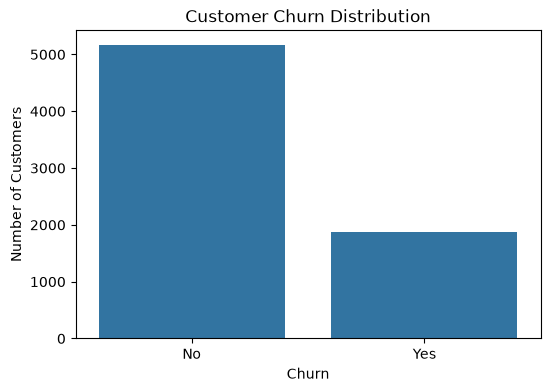

In [48]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../Images", exist_ok=True)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.savefig("../Images/churn_distribution.png", bbox_inches="tight")
plt.show()

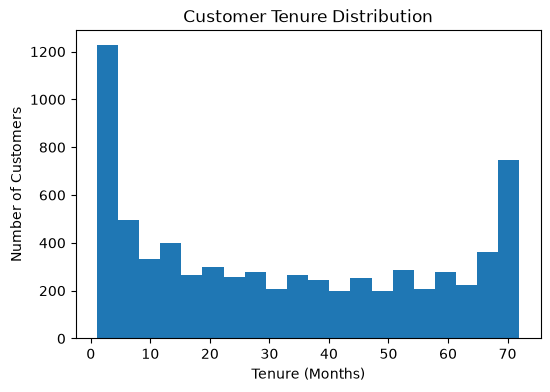

In [49]:
plt.figure(figsize=(6, 4))

plt.hist(df["tenure"], bins=20)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.savefig("../Images/tenure_distribution.png", bbox_inches="tight")
plt.show()

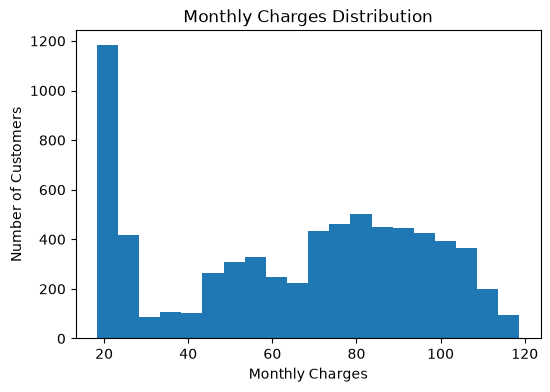

In [50]:
plt.figure(figsize=(6, 4))

plt.hist(df["MonthlyCharges"], bins=20)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.savefig("../Images/monthly_charges_distribution.png", bbox_inches="tight")
plt.show()

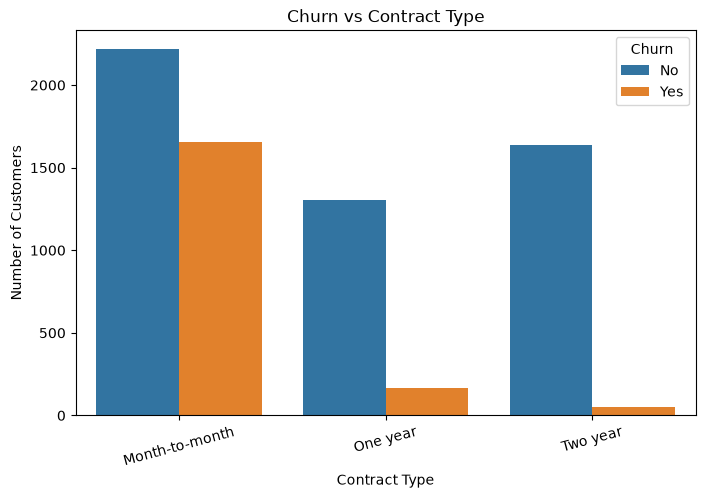

In [51]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Churn vs Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

plt.savefig("../Images/churn_contract.png", bbox_inches="tight")
plt.show()

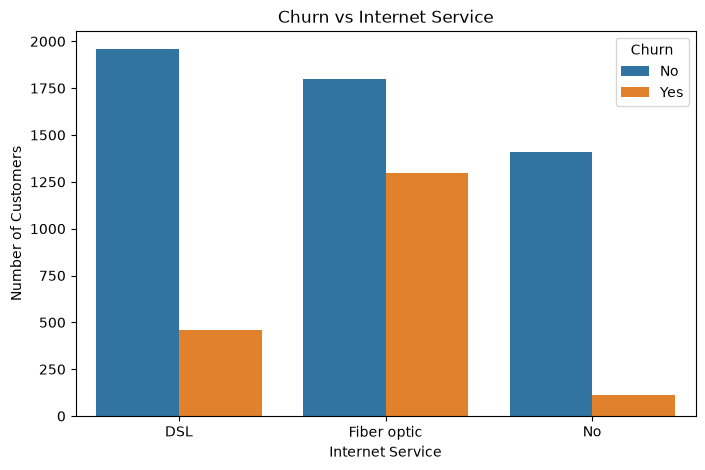

In [52]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Churn vs Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.savefig("../Images/churn_internet_service.png", bbox_inches="tight")
plt.show()

In [53]:
print(type(model))
print(type(y_test))
print(type(y_pred_proba))

<class 'sklearn.pipeline.Pipeline'>
<class 'pandas.Series'>


NameError: name 'y_pred_proba' is not defined

In [54]:
# Generate probability predictions for the positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Probability predictions generated successfully!")
print("Number of predictions:", len(y_pred_proba))

Probability predictions generated successfully!
Number of predictions: 1407


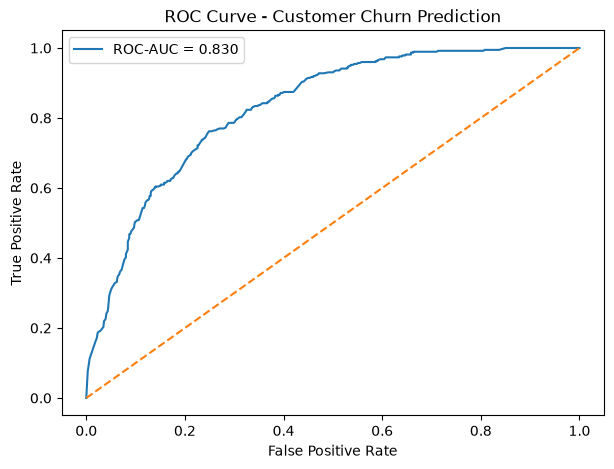

ROC-AUC: 0.8295668086824627


In [55]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Customer Churn Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig("../Images/roc_curve.png", bbox_inches="tight")
plt.show()

print("ROC-AUC:", roc_auc)